# Figures 1-2: background equation of state and WKB matching

Reproduces `eos.pdf` (Fig. 1) and `eta_wkb.pdf` (Fig. 2) of the Draft
directly from `core/background_qcd.py`, which solves the QCD-crossover
background (lattice-QCD `g_rho(T), g_s(T)` stitched to the Saikawa-Shirai
fit) at import time. No stored tables are needed for this notebook.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../core"))
import numpy as np
import matplotlib.pyplot as plt

import plotstyle; plotstyle.use_latex()
plt.rcParams.update({
    "font.size": 16, "axes.labelsize": 19, "axes.titlesize": 17,
    "legend.fontsize": 13.5, "xtick.labelsize": 16, "ytick.labelsize": 16,
})

import kernel as K
import spectra as sp
import background_qcd as qcd
import modes

FIGDIR = os.path.abspath("../../Draft/Figures")
NHZ_TO_HZ = 1e-9

T_OBS_S = 16.0 * 365.25 * 24.0 * 3600.0
PTA_F_LO_HZ = 1.0 / T_OBS_S
PTA_F_HI_HZ = 20.0 / T_OBS_S
PTA_K_LO = float(sp.f_Hz_to_k(np.array([PTA_F_LO_HZ]))[0])
PTA_K_HI = float(sp.f_Hz_to_k(np.array([PTA_F_HI_HZ]))[0])


def add_pta_band(ax, kind="k"):
    lo, hi = (PTA_K_LO, PTA_K_HI) if kind == "k" else (PTA_F_LO_HZ, PTA_F_HI_HZ)
    ax.axvspan(lo, hi, color="0.85", zorder=0, lw=0)

background_qcd: solving coupled continuity-equation ODE for T(eta), a(eta) (g_rho, g_s, w from lattice_gstar.py)...
  norm = 1.0032620737


### Horizon-crossing maps: $k=\mathcal{H}(\eta)\to\eta_\ast(k),\,T(k)$

In [2]:
_eta_grid = np.geomspace(2e-12, 1.0, 4000)
_H_grid = np.array([float(qcd.H_of_eta(np.asarray(e))) for e in _eta_grid])
_T_grid = np.array([float(qcd.T_of_eta(np.asarray(e))) for e in _eta_grid])


def eta_of_k_hor(k):
    return np.interp(np.log(k), np.log(_H_grid[::-1]), np.log(_eta_grid[::-1]))


def T_of_k_hor(k):
    lg_eta = eta_of_k_hor(np.asarray(k, dtype=float))
    return np.exp(np.interp(lg_eta, np.log(_eta_grid), np.log(_T_grid)))


def add_T_axis(ax, T_ticks_gev, labels):
    k_lo, k_hi = ax.get_xlim()
    kk = np.geomspace(k_lo, k_hi, 400)
    TT = T_of_k_hor(kk)
    sec = ax.twiny()
    sec.set_xscale("log")
    sec.set_xlim(k_lo, k_hi)
    kpos = [np.exp(np.interp(np.log(T), np.log(TT), np.log(kk))) for T in T_ticks_gev]
    sec.set_xticks(kpos, labels)
    sec.minorticks_off()
    sec.set_xlabel(r"$T\,[\mathrm{GeV}]$", labelpad=10)
    return sec

## Figure 1: equation of state at horizon crossing

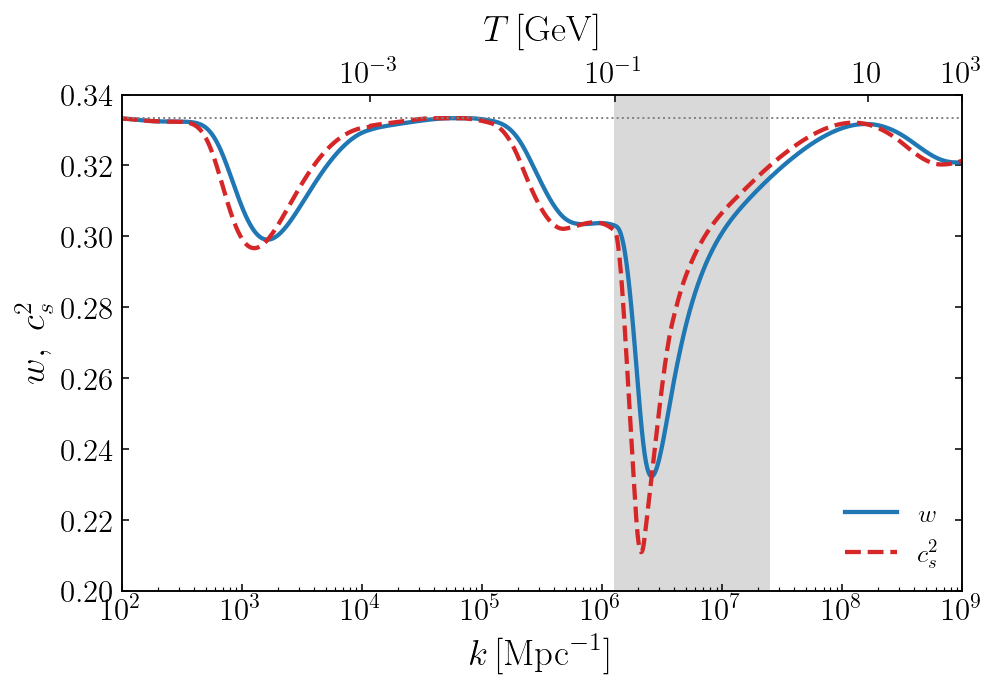

saved eos.pdf


In [3]:
kk = np.geomspace(1e2, 1e9, 1200)
eta = np.exp(eta_of_k_hor(kk))
w = np.array([float(qcd.w_of_eta(np.asarray(e))) for e in eta])
cs2 = np.array([float(qcd.cs2_of_eta(np.asarray(e))) for e in eta])

fig, ax = plt.subplots(figsize=(7.4, 5.2))
add_pta_band(ax, "k")
ax.semilogx(kk, w, lw=2.2, color="C0", label=r"$w$")
ax.semilogx(kk, cs2, lw=2.2, color="C3", ls="--", label=r"$c_s^2$")
ax.axhline(1.0 / 3.0, color="0.5", lw=1.0, ls=":")
ax.set_xlim(1e2, 1e9)
ax.set_ylim(0.2, 0.34)
ax.set_xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
ax.set_ylabel(r"$w,\ c_s^2$")
ax.legend(loc="lower right")
add_T_axis(ax, [1e-3, 1e-1, 1e1, 1e3], [r"$10^{-3}$", r"$10^{-1}$", r"$10$", r"$10^{3}$"])
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "eos.pdf"))
plt.show()
print("saved eos.pdf")

## Figure 2: WKB-matching time $\eta_{\rm WKB}(k)$

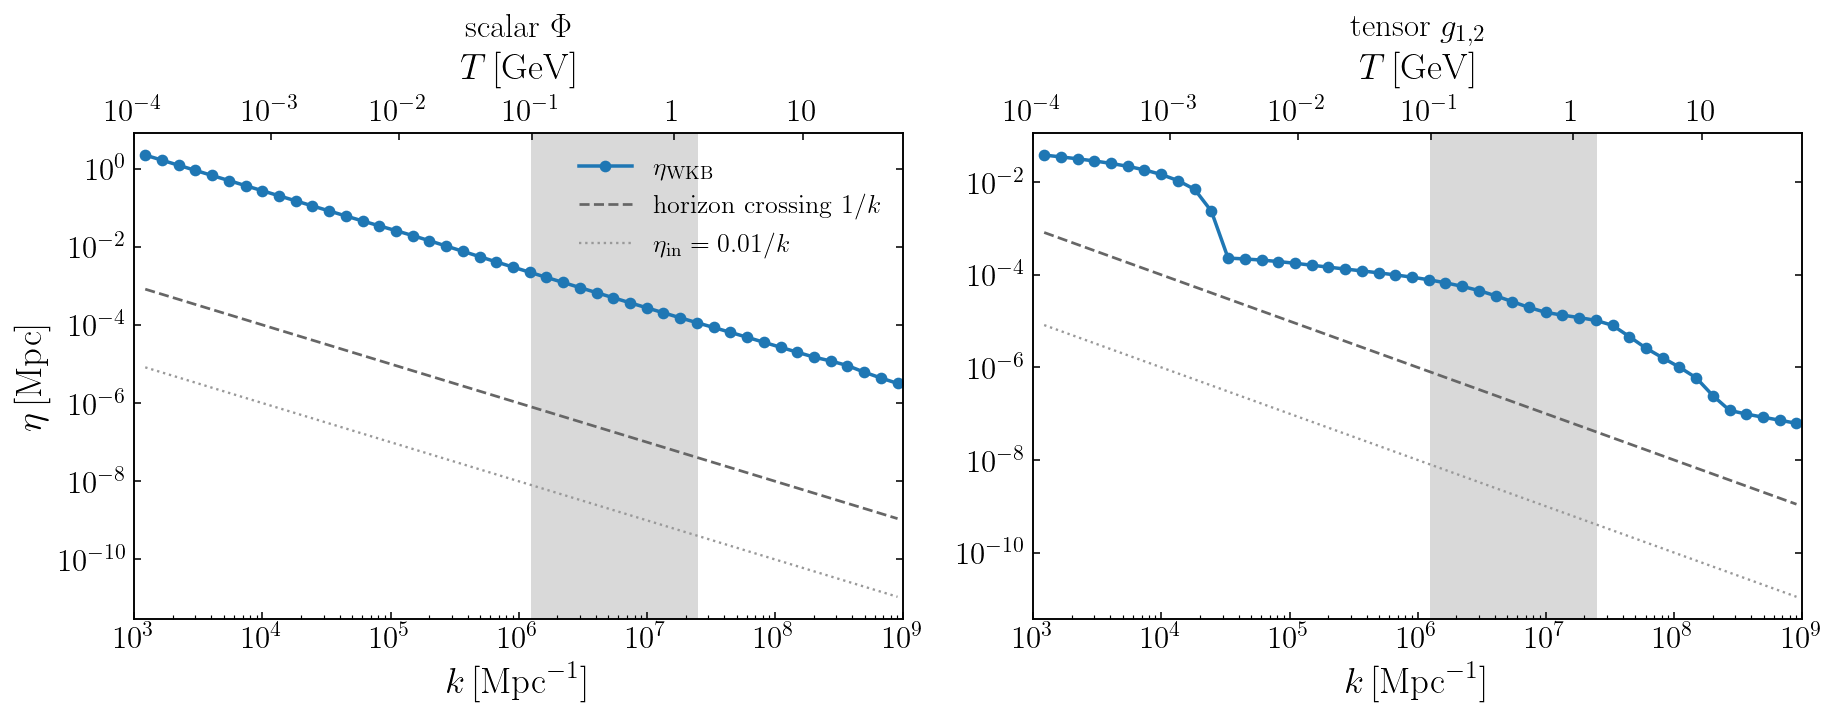

saved eta_wkb.pdf


In [4]:
k = np.geomspace(3.0, 3e9, 70)
ein = K.ETA_IN_FACTOR / k
eta_hi_scan = 1e4 / k
ewp = np.array([float(modes.find_eta_wkb(ki, qcd.f1_Phi, qcd.f2_Phi, qcd.f3_Phi, ei, eh)[0])
                for ki, ei, eh in zip(k, ein, eta_hi_scan)])
ewg = np.array([float(modes.find_eta_wkb(ki, qcd.f1_g, qcd.f2_g, qcd.f3_g, ei, eh)[0])
                for ki, ei, eh in zip(k, ein, eta_hi_scan)])
m = (k >= 1e3) & (k <= 1e9)

fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.4))
for ax, ew, ttl in [(axes[0], ewp[m], r"scalar $\Phi$"),
                    (axes[1], ewg[m], r"tensor $g_{1,2}$")]:
    add_pta_band(ax, "k")
    ax.loglog(k[m], ew, "o-", ms=5, lw=1.8, color="C0", label=r"$\eta_{\rm WKB}$")
    ax.loglog(k[m], 1.0 / k[m], lw=1.4, color="0.4", ls="--", label=r"horizon crossing $1/k$")
    ax.loglog(k[m], ein[m], lw=1.2, color="0.6", ls=":", label=r"$\eta_{\rm in}=0.01/k$")
    ax.set_xlim(1e3, 1e9)
    ax.set_xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
    ax.set_title(ttl, fontsize=17, pad=8)
    add_T_axis(ax, [1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1],
               [r"$10^{-4}$", r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$1$", r"$10$"])
axes[0].set_ylabel(r"$\eta\,[\mathrm{Mpc}]$")
axes[0].legend(loc="upper right")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "eta_wkb.pdf"))
plt.show()
print("saved eta_wkb.pdf")